In [1]:
# =================================================================
# PARTE 1 - DIAGNÓSTICO ESTRATÉGICO DE DADOS
# =================================================================

def diagnostico_estrategico():
    print("=== PARTE 1: DIAGNÓSTICO ESTRATÉGICO ===")

    # Aplicação dos 5Vs do Big Data no contexto do projeto
    v_dict = {
        "Volume": "Processamento de 20.640 registros da base California Housing.",
        "Velocidade": "Análise em tempo real para tomada de decisão imobiliária.",
        "Variedade": "Dados estruturados (tabelas) e não estruturados (feedbacks de clientes).",
        "Veracidade": "Tratamento de dados e normalização para garantir previsões confiáveis.",
        "Valor": "Geração de inteligência competitiva para precificação e investimentos."
    }

    for v, descricao in v_dict.items():
        print(f"✓ {v}: {descricao}")

    print("\nClassificação dos Dados:")
    print("- Estruturados: Preços, quartos, latitude/longitude.")
    print("- Não Estruturados: Comentários de clientes e avaliações em texto.")

diagnostico_estrategico()

=== PARTE 1: DIAGNÓSTICO ESTRATÉGICO ===
✓ Volume: Processamento de 20.640 registros da base California Housing.
✓ Velocidade: Análise em tempo real para tomada de decisão imobiliária.
✓ Variedade: Dados estruturados (tabelas) e não estruturados (feedbacks de clientes).
✓ Veracidade: Tratamento de dados e normalização para garantir previsões confiáveis.
✓ Valor: Geração de inteligência competitiva para precificação e investimentos.

Classificação dos Dados:
- Estruturados: Preços, quartos, latitude/longitude.
- Não Estruturados: Comentários de clientes e avaliações em texto.



=== PARTE 2: ANÁLISE EXPLORATÓRIA ===


'Resumo Estatístico:'

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


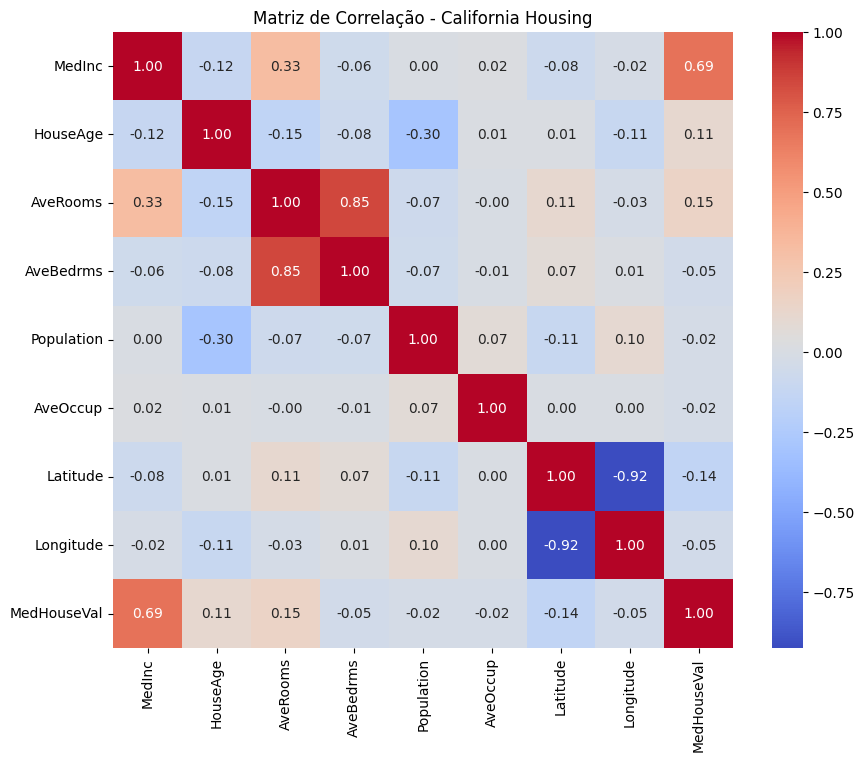

In [9]:
# =================================================================
# PARTE 2 - ANÁLISE EXPLORATÓRIA (P2)
# =================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

print("\n=== PARTE 2: ANÁLISE EXPLORATÓRIA ===")

# Importação da base California Housing
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

# Exibição das estatísticas descritivas
display('Resumo Estatístico:')
display(df.describe())

# Geração da Matriz de Correlação
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação - California Housing")
plt.show()

In [3]:
# =================================================================
# PARTE 3 - MODELAGEM (PCA, K-MEANS, REGRESSÃO)
# =================================================================
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

print("\n=== PARTE 3: MODELAGEM ===")

# 1. Normalização (Essencial para PCA e K-means)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.drop('MedHouseVal', axis=1))

# 2. PCA (Redução de Dimensionalidade)
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
print(f"✓ Variância explicada pelo PCA (2 componentes): {pca.explained_variance_ratio_.sum():.2f}")

# 3. K-means (Segmentação/Clusterização)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df_scaled)
print("✓ Clusters socioeconômicos gerados com sucesso.")

# 4. Regressão Linear Múltipla (Predição de Preço)
from sklearn.model_selection import train_test_split

X = df.drop(['MedHouseVal', 'Cluster'], axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"\nResultados da Regressão:")
print(f"- R² do Modelo (Precisão): {r2_score(y_test, y_pred):.4f}")
print(f"- Erro Quadrático Médio (MSE): {mean_squared_error(y_test, y_pred):.4f}")


=== PARTE 3: MODELAGEM ===
✓ Variância explicada pelo PCA (2 componentes): 0.49
✓ Clusters socioeconômicos gerados com sucesso.

Resultados da Regressão:
- R² do Modelo (Precisão): 0.5758
- Erro Quadrático Médio (MSE): 0.5559


In [4]:
# =================================================================
# PARTE 4 - ANÁLISE DE FLUXO (CENÁRIO E-COMMERCE)
# =================================================================
print("\n=== PARTE 4: ANÁLISE DE FLUXO ===")

# Dados do Funil de Vendas
fluxo = {
    'Etapa': ['Visitas', 'Carrinho', 'Checkout', 'Pagamento'],
    'Usuarios': [10000, 4500, 1200, 1000]
}
df_fluxo = pd.DataFrame(fluxo)

# Cálculo de perda percentual entre etapas
df_fluxo['Perda_Percentual'] = df_fluxo['Usuarios'].pct_change().fillna(0) * -1

# Identificação da maior perda
etapa_gargalo = df_fluxo.loc[df_fluxo['Perda_Percentual'].idxmax(), 'Etapa']
taxa_conv = (df_fluxo.iloc[-1]['Usuarios'] / df_fluxo.iloc[0]['Usuarios']) * 100

display(df_fluxo)
print(f"\nAnálise Gerencial:")
print(f"- O gargalo do fluxo está na etapa: {etapa_gargalo}")
print(f"- Taxa de Conversão Final: {taxa_conv}%")


=== PARTE 4: ANÁLISE DE FLUXO ===


,Etapa,Usuarios,Perda_Percentual
0,Visitas,10000,-0.000000
1,Carrinho,4500,0.550000
2,Checkout,1200,0.733333
3,Pagamento,1000,0.166667



Análise Gerencial:
- O gargalo do fluxo está na etapa: Checkout
- Taxa de Conversão Final: 10.0%


In [5]:
# =================================================================
# PARTE 5 - MINERAÇÃO DE TEXTO
# =================================================================
print("\n=== PARTE 5: MINERAÇÃO DE TEXTO ===")

comentarios = [
    "Ótima localização, mas o preço está muito alto",
    "Casa velha e mal cuidada, não gostei",
    "Excelente oportunidade de investimento, amei",
    "O processo de compra foi muito lento e burocrático",
    "Adorei o atendimento e a clareza dos dados"
]

# Dicionários de termos para análise de sentimentos
palavras_positivas = ['ótima', 'excelente', 'amei', 'adorei', 'clareza']
palavras_negativas = ['alto', 'velha', 'lento', 'burocrático', 'não gostei']

def analisar_sentimento(texto):
    texto = texto.lower()
    score_pos = sum(1 for p in palavras_positivas if p in texto)
    score_neg = sum(1 for p in palavras_negativas if p in texto)

    if score_pos > score_neg: return 'Positivo'
    elif score_neg > score_pos: return 'Negativo'
    return 'Neutro'

print("Classificação de Feedbacks:")
for c in comentarios:
    sentimento = analisar_sentimento(c)
    print(f"[{sentimento}] -> {c}")

print("\n--- Processamento Finalizado ---")



=== PARTE 5: MINERAÇÃO DE TEXTO ===
Classificação de Feedbacks:
[Neutro] -> Ótima localização, mas o preço está muito alto
[Negativo] -> Casa velha e mal cuidada, não gostei
[Positivo] -> Excelente oportunidade de investimento, amei
[Negativo] -> O processo de compra foi muito lento e burocrático
[Positivo] -> Adorei o atendimento e a clareza dos dados

--- Processamento Finalizado ---


In [6]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import plotly.express as px

# Re-criação do DataFrame 'df' e da coluna 'Cluster' para garantir a execução
# Esta parte é duplicada das células anteriores para que a célula de plotagem
# possa ser executada de forma independente e resolver o NameError.
# Importação da base California Housing
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

# Normalização (Essencial para K-means)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.drop('MedHouseVal', axis=1))

# K-means (Segmentação/Clusterização)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df_scaled)


# Criando um gráfico de dispersão interativo para visualizar os clusters
# Usamos Renda Média (MedInc) vs Preço da Casa (MedHouseVal)
fig_clusters = px.scatter(df,
                         x="MedInc",
                         y="MedHouseVal",
                         color="Cluster",
                         title="Segmentação de Regiões por Perfil Socioeconômico (K-means)",
                         labels={"MedInc": "Renda Média", "MedHouseVal": "Preço Médio da Casa"},
                         color_continuous_scale=px.colors.qualitative.Safe)

fig_clusters.show()

In [7]:
import plotly.graph_objects as go
import plotly.express as px # Added import
import pandas as pd # Needed for df_fluxo
from sklearn.metrics import r2_score # Added import

# --- Imports e Dados para o Cálculo de KPIs ---
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression

# Re-define df_fluxo e taxa_conv para auto-contenção
# Dados da PARTE 4
fluxo = {
    'Etapa': ['Visitas', 'Carrinho', 'Checkout', 'Pagamento'],
    'Usuarios': [10000, 4500, 1200, 1000]
}
df_fluxo = pd.DataFrame(fluxo)
df_fluxo['Perda_Percentual'] = df_fluxo['Usuarios'].pct_change().fillna(0) * -1
taxa_conv = (df_fluxo.iloc[-1]['Usuarios'] / df_fluxo.iloc[0]['Usuarios']) * 100

# --- Re-inicializa df, Cluster, y, e y_pred para cálculos de KPI ---
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

# Normalização (Essencial para PCA e K-means)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.drop('MedHouseVal', axis=1))

# K-means (Segmentação/Clusterização) - para obter a coluna 'Cluster'
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df_scaled)

# Regressão Linear Múltipla (Predição de Preço) - para obter y e y_pred
X = df.drop(['MedHouseVal', 'Cluster'], axis=1)
y = df['MedHouseVal']
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# --- Cartões de KPI (Indicadores de Desempenho) ---
kpi_conversao = f"{taxa_conv:.1f}%"
kpi_ticket_medio = f"${df['MedHouseVal'].mean():.2f}k"
kpi_r2_modelo = f"{r2_score(y, y_pred):.2f}"

fig_kpi = go.Figure()

fig_kpi.add_trace(go.Indicator(
    mode = "number",
    value = taxa_conv,
    title = {"text": "Taxa de Conversão Final"},
    domain = {'x': [0, 0.33], 'y': [0, 1]}))

fig_kpi.add_trace(go.Indicator(
    mode = "number",
    value = df['MedHouseVal'].mean(),
    number = {'prefix': "$", 'suffix': "k"},
    title = {"text": "Preço Médio Global"},
    domain = {'x': [0.34, 0.66], 'y': [0, 1]}))

fig_kpi.add_trace(go.Indicator(
    mode = "number",
    value = r2_score(y, y_pred),
    title = {"text": "Precisão do Modelo (R²)"},
    domain = {'x': [0.67, 1], 'y': [0, 1]}))

fig_kpi.update_layout(title="Painel de KPIs Estratégicos")
fig_kpi.show()

# --- Gráfico de Funil ---
fig_funil = px.funnel(df_fluxo,
                      x='Usuarios',
                      y='Etapa',
                      title='Funil de Vendas: Identificação de Gargalos')
fig_funil.show()